## Name: Reem Alyahya

---
title: "Project 1: Fast Food Marketing Campaign A/B Test"
---

## Project Overview
  
Evaluating three marketing promotions for a new menu item using A/B testing to determine the most effective strategy based on sales performance.

## Objectives
  
  * Compare sales of three different promotions.
  * Apply statistical analysis to confirm the significance.
  * Decide which promotion campaign is the best to use.


## Data Features
* Promotion: tested marketing campaign.
* SalesInThousands: target sales metric.
* Week: week of the promotin.
* AgeOfStore: store age in years.


---------------------

### import  needed libraries:

In [76]:
# Standard libraries
from pathlib import Path

# Installed libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuration
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')
np.random.seed(42)

### Data Loading:
loading campaign data to start the analysis

In [59]:
df = pd.read_csv('WA_Marketing-Campaign.csv')
df

,MarketID,MarketSize,LocationID,AgeOfStore,Promotion,week,SalesInThousands
0,1,Medium,1,4,3,1,33.73
1,1,Medium,1,4,3,2,35.67
2,1,Medium,1,4,3,3,29.03
3,1,Medium,1,4,3,4,39.25
4,1,Medium,2,5,2,1,27.81
...,...,...,...,...,...,...,...
543,10,Large,919,2,1,4,64.34
544,10,Large,920,14,2,1,50.20
545,10,Large,920,14,2,2,45.75
546,10,Large,920,14,2,3,44.29


`Data is successfully loaded with 548 rows and 7 columns that contains [AgeOfStore, Promootion, week, SalesInThousands].`

In [61]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


### Findings:
* The DataFrame is clean with no missing values.
* All columns have the correct types.

## Confirmatory data analysis (CDA):
In this section, we will calculate the `mean()`, `std()` and `count()` of each promotion group, This allows us to compare their performance.

In [64]:
# Calculate promotions sales average:

df.groupby('Promotion')['SalesInThousands'].agg(['mean', 'std', 'count'])

,mean,std,count
Promotion,,,
1,58.099012,16.553782,172
2,47.329415,15.108955,188
3,55.364468,16.766231,188


### Findings:
* **Promotion1** have the highest sales in average, while the **Promotion2** have the lowest.
* **The Standard deviation** is consistent between groups.
* **The observations of count** are compareable (172 - 188).


   `Now we need to verify if these results are statistically significant `

----------------

## Hypothesis Testing:
We want to define two hypotheses:
* **Null Hypothesis ($H_0$):**

    There is no significant difference in sales between **Promotion1** and **Promotion2**.
* **Alternative Hypothesis ($H_a$):**

    **Promotion1**  has a significantly higher sales mean compared to **Promotion2**.

### Data Visualization and Exploration:
Now let's look at some charts to see how sales actually compare between **Promotiion1** and **Promotion2**.
In figure below and since the type of our data is categorical-numerical we will find two types of charts:
* **Histogram:** shows us where most of the sales are happening for each campaign.
* **KDE plot:** Gives a smooth curve to show which promotion is shifted to higher sales.

In [103]:
df_1_2 = df[df['Promotion'].isin([1,2])]

In [104]:
warnings.filterwarnings('ignore')

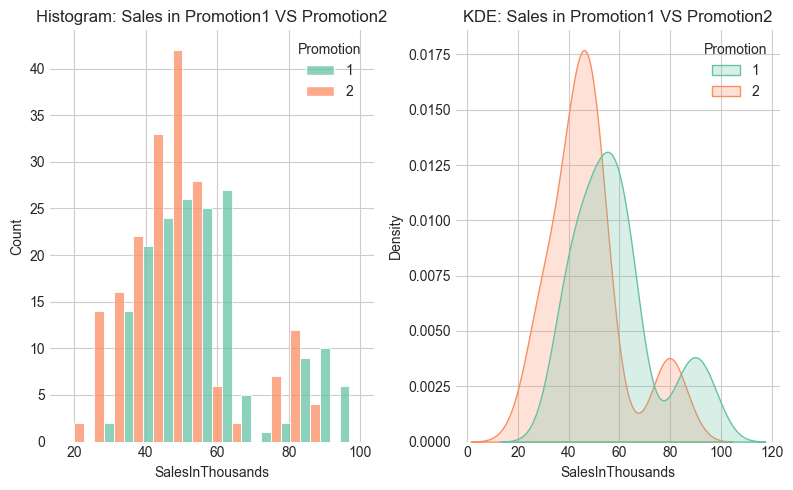

In [105]:
#Figures to compare Promotion1 to Promotion2:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,5))

sns.histplot(

x = 'SalesInThousands',
hue=  'Promotion',
data = df_1_2,
bins = 15,
palette= 'Set2',
multiple= 'dodge',
ax = ax1

)
ax1.set_title('Histogram: Sales in Promotion1 VS Promotion2')

sns.kdeplot(

x = 'SalesInThousands',
hue=  'Promotion',
data = df_1_2,
fill= True,
palette= 'Set2',
ax = ax2

)

ax2.set_title('KDE: Sales in Promotion1 VS Promotion2')

plt.tight_layout()
plt.show()

### Findings:
Looking at figures above we can observe:
* The **Promotion1** curve in KDE is shifted more to the right compared to **Promotion2** which means higher sales performance.
* Histogram shows that **Promotion1** has more bars on the right side which means it reached higher sales numbers more often than **Promotion2**.
**The charts suggest that Promotion1 is better than Promotion2, but we have to use t-test to make sure this difference is significant or not.**

-----------

## Statistical Significant Testing (T-test):
   Since we want to compare between performances of the promotions, we will use an **Independent testing** using `ttest_ind()`. 
   This is help to know the difference between **Promotion1** and **Promotion2** is statistically significant or not.

In [106]:
# significance level

alpha = 0.05

In [117]:
t_statistic, p_value = stats.ttest_ind(

df[df['Promotion'] == 1]['SalesInThousands'],
df[df['Promotion'] == 2]['SalesInThousands']

)
print(p_value)
if p_value <= alpha:
    print("Conclusion: Promotion 1 is significantly has better outcomes than Promotion 2")
else:
    print("Conclusion: not enough evidence to support the claim that Promotion 1 has better outcomes than Promotion2.")


3.5506696512134597e-10
Conclusion: Promotion 1 is significantly has better outcomes than Promotion 2


### Findings:
After running `ttest_ind()` here is the outcomes:
* `p_value` = 0.0000000003551 which is definitely less than `alpha`.
* The test confirms that  **Promotion1** is better in sales than **Promotion2**.

    `This proves the alternative hypothesis`

------------------

### Now lets compare Promotion1 to Promotion3:
based on `mean()` of sales of Promotion1 and Promotion3 we will start a new Hypothesis.

----------------

## Hypothesis Testing:
We want to define two hypotheses:
* **Null Hypothesis ($H_0$):**

    There is no significant difference in sales between **Promotion1** and **Promotion3**.
* **Alternative Hypothesis ($H_a$):**

    **Promotion1**  has a significantly higher sales mean compared to **Promotion3**.

### Data Visualization and Exploration:
Now let's look at some charts to see how sales actually compare between **Promotion1** and **Promotion3**.
In figure below and since the type of our data is categorical-numerical we will find two types of charts:
* **Histogram:** shows us where most of the sales are happening for each campaign.
* **KDE plot:** Gives a smooth curve to show which promotion is shifted to higher sales.

In [108]:
df_1_3 = df[df['Promotion'].isin([1,3])]

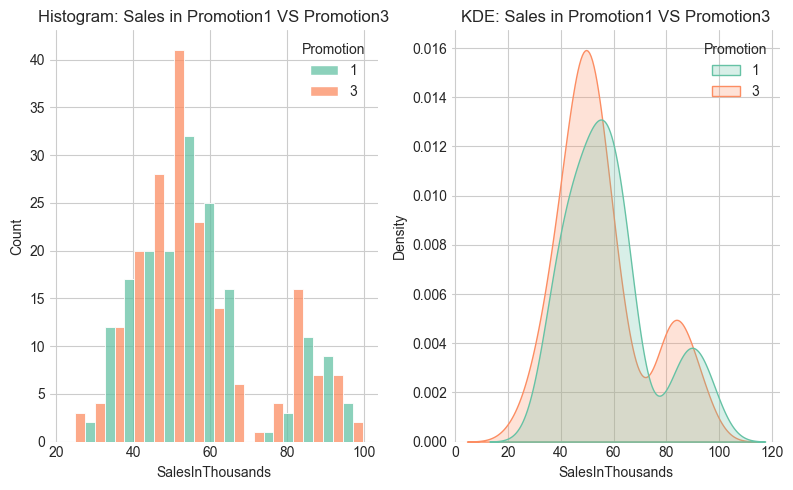

In [116]:
#Figures to compare Promotion1 to Promotion3:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,5))

sns.histplot(

x = 'SalesInThousands',
hue=  'Promotion',
data = df_1_3,
bins = 15,
palette= 'Set2',
multiple= 'dodge',
ax = ax1

)
ax1.set_title('Histogram: Sales in Promotion1 VS Promotion3')

sns.kdeplot(

x = 'SalesInThousands',
hue=  'Promotion',
data = df_1_3,
fill= True,
palette= 'Set2',
ax = ax2

)


ax2.set_title('KDE: Sales in Promotion1 VS Promotion3')

plt.tight_layout()
plt.show()

### Findings:
Looking at figures above we can observe:
* The curves in KDE almost overlapping, their peaks are very close, which means that their performances are nearly the same.
* Histogram shows a very similar pattern between sales in **Promotion1** and **Promotion3**, there is no clear gap or significant different between the two groups.
**The charts suggest that there is no significant difference between Promotion1 and Promotion3, but we need to test the result statistically**

---

## Statistical Significant Testing (T-test):
   Since we want to compare between performances of the promotions, we will use an **Independent testing** using `ttest_ind()`. 
   This is help to know the difference between **Promotion1** and **Promotion3** is statistically significant or not.

In [120]:
t_statistic, p_value = stats.ttest_ind(

df[df['Promotion'] == 1]['SalesInThousands'],
df[df['Promotion'] == 3]['SalesInThousands']

)
print(p_value)
if p_value <= alpha:
    print("Conclusion: Promotion 1 is significantly has better outcomes than Promotion 2")
else:
    print("Conclusion: not enough evidence to support the claim that Promotion1 has better outcomes than Promotion3.")


0.12079667272313269
Conclusion: not enough evidence to support the claim that Promotion1 has better outcomes than Promotion3.


### Findings:
After running `ttest_ind()` here is the outcomes:
* `p_value` = 0.12079667272313269 which is greater than `alpha`.
* This means we don't have enough evedence to say there is a significant difference between Promotion1 and Promotion3.
* Both promotions perform similary in terms of sales.

    `we failed to reject the Null hypothesis`

---

### Now lets compare Promotion2 to Promotion3:
based on `mean()` of sales of Promotion2 and Promotion3 we will start a new Hypothesis.

## Hypothesis Testing:
We want to define two hypotheses:
* **Null Hypothesis ($H_0$):**

    There is no significant difference in sales between **Promotion2** and **Promotion3**.
* **Alternative Hypothesis ($H_a$):**

    **Promotion3**  has a significantly higher sales mean compared to **Promotion2**.

### Data Visualization and Exploration:
Now let's look at some charts to see how sales actually compare between **Promotion2** and **Promotion3**.
In figure below and since the type of our data is categorical-numerical we will find two types of charts:
* **Histogram:** shows us where most of the sales are happening for each campaign.
* **KDE plot:** Gives a smooth curve to show which promotion is shifted to higher sales.

In [121]:
df_2_3 = df[df['Promotion'].isin([2,3])]

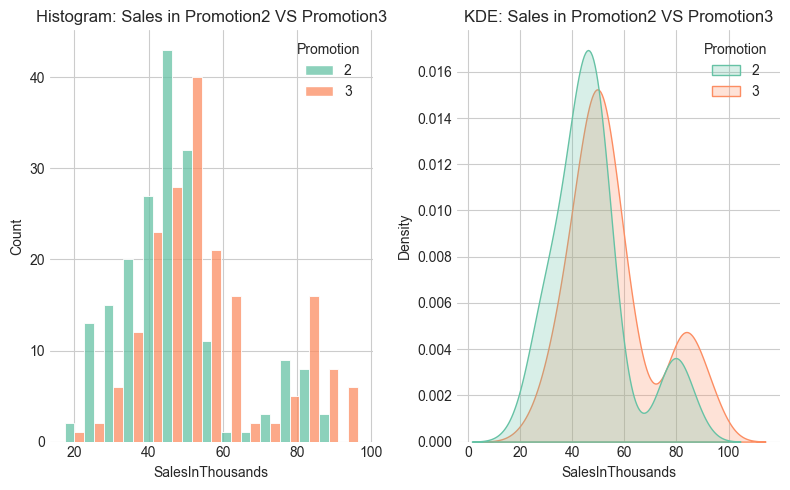

In [122]:
#Figures to compare Promotion2 to Promotion3:


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,5))

sns.histplot(

x = 'SalesInThousands',
hue=  'Promotion',
data = df_2_3,
bins = 15,
palette= 'Set2',
multiple= 'dodge',
ax = ax1

)
ax1.set_title('Histogram: Sales in Promotion2 VS Promotion3')

sns.kdeplot(

x = 'SalesInThousands',
hue=  'Promotion',
data = df_2_3,
fill= True,
palette= 'Set2',
ax = ax2

)


ax2.set_title('KDE: Sales in Promotion2 VS Promotion3')

plt.tight_layout()
plt.show()

### Findings:
Looking at figures above we can observe:
* The **Promotion3** curve in KDE is shifted more to the right compared to **Promotion2** which means higher sales performance.
* Histogram shows that **Promotion3** has more bars on the right side which means it reached higher sales numbers more often than **Promotion2**.
**The charts suggest that Promotion3 is better than Promotion2, but we have to use t-test to make sure this difference is significant or not.**

---

## Statistical Significant Testing (T-test):
   Since we want to compare between performances of the promotions, we will use an **Independent testing** using `ttest_ind()`. 
   This is help to know the difference between **Promotion2** and **Promotion3** is statistically significant or not.

In [125]:
t_statistic, p_value = stats.ttest_ind(

df[df['Promotion'] == 3]['SalesInThousands'],
df[df['Promotion'] == 2]['SalesInThousands']

)
print(p_value)
if p_value <= alpha:
    print("Conclusion: Promotion 3 is significantly has better outcomes than Promotion 2")
else:
    print("Conclusion: not enough evidence to support the claim that Promotion3 has better outcomes than Promotion2.")


1.5628943036277334e-06
Conclusion: Promotion 3 is significantly has better outcomes than Promotion 2


### Findings:
After running `ttest_ind()` here is the outcomes:
* `p_value` =  1.5628943036277334e-06 which is definitely less than `alpha`.
* The test confirms that  **Promotion3** is better in sales than **Promotion2**.

    `This proves the alternative hypothesis`